# Unified Metrics Comparison: All Methods

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi

RESULTS_DIR = "comparison_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

def parse_csv_value(raw_val):
    if raw_val is None or raw_val == '—' or str(raw_val).strip() == '':
        return None
    s = str(raw_val).strip()
    s = re.sub(r'__PERSONAL_\d+__', '', s)
    try:
        return float(s)
    except ValueError:
        return None

def read_all_metrics():
    mob_path = "mobilenet_lut_results/comparison_table.csv"
    mob_df = pd.read_csv(mob_path) if os.path.exists(mob_path) else None
    
    ada_path = "adaptive_lut_results/comparison_table.csv"
    ada_df = pd.read_csv(ada_path) if os.path.exists(ada_path) else None
    
    base_path = "baseline_results/baseline_metrics.csv"
    base_df = pd.read_csv(base_path, index_col=0) if os.path.exists(base_path) else None
    
    static_path = "lut_results/static_lut_metrics.csv"
    static_metrics = {}
    if os.path.exists(static_path):
        static_raw = pd.read_csv(static_path, header=None, skiprows=1, index_col=0)
        for idx in static_raw.index:
            key = str(idx).strip()
            val_raw = static_raw.loc[idx].values[0] if static_raw.loc[idx].values.size > 0 else None
            static_metrics[key] = val_raw

    all_metrics = {}
    
    def get_val(df, method_col, metric, value_col=None):
        if df is None:
            return None
        if value_col is None:
            value_col = metric
        row = df[df[method_col].str.strip().str.lower() == metric.lower()]
        if len(row) == 0:
            return None
        return parse_csv_value(row.iloc[0][value_col])
    
    orig_psnr = get_val(ada_df, 'Method', 'Original', 'PSNR')
    orig_ssim = get_val(ada_df, 'Method', 'Original', 'SSIM')
    orig_delta = get_val(ada_df, 'Method', 'Original', 'Delta E')
    all_metrics['Original'] = {'psnr': orig_psnr, 'ssim': orig_ssim, 'delta_e': orig_delta, 'time_ms': None, 'params_m': 0, 'type': 'Reference'}
    
    classic_names = ['gamma', 'histogram', 'clahe', 'combined']
    classic_display = ['Gamma', 'Histogram', 'CLAHE', 'Combined']
    
    for cname, cdisp in zip(classic_names, classic_display):
        psnr_v = get_val(mob_df, 'Method', cname, 'PSNR')
        ssim_v = get_val(mob_df, 'Method', cname, 'SSIM')
        delta_v = get_val(mob_df, 'Method', cname, 'Delta E')
        time_v = get_val(mob_df, 'Method', cname, 'Time (ms)')
        
        if base_df is not None and cname in base_df.index:
            psnr_v = parse_csv_value(base_df.loc[cname, 'psnr'])
            ssim_v = parse_csv_value(base_df.loc[cname, 'ssim'])
            delta_v = parse_csv_value(base_df.loc[cname, 'delta_e'])
            time_v_sec = parse_csv_value(base_df.loc[cname, 'avg_time'])
            time_v = time_v_sec * 1000 if time_v_sec is not None else None
        
        all_metrics[cdisp] = {'psnr': psnr_v, 'ssim': ssim_v, 'delta_e': delta_v, 'time_ms': time_v, 'params_m': 0, 'type': 'Classic'}
    
    sl_psnr = parse_csv_value(static_metrics.get('psnr'))
    sl_ssim = parse_csv_value(static_metrics.get('ssim'))
    sl_delta = parse_csv_value(static_metrics.get('delta_e'))
    sl_time = get_val(mob_df, 'Method', 'Static LUT', 'Time (ms)')
    
    all_metrics['Static LUT'] = {'psnr': sl_psnr, 'ssim': sl_ssim, 'delta_e': sl_delta, 'time_ms': sl_time, 'params_m': 0.1, 'type': 'LUT-based'}
    
    al_psnr = get_val(ada_df, 'Method', 'Adaptive LUT', 'PSNR') or get_val(mob_df, 'Method', 'Adaptive LUT', 'PSNR')
    al_ssim = get_val(ada_df, 'Method', 'Adaptive LUT', 'SSIM') or get_val(mob_df, 'Method', 'Adaptive LUT', 'SSIM')
    al_delta = get_val(ada_df, 'Method', 'Adaptive LUT', 'Delta E') or get_val(mob_df, 'Method', 'Adaptive LUT', 'Delta E')
    al_time = get_val(ada_df, 'Method', 'Adaptive LUT', 'Time (ms)') or get_val(mob_df, 'Method', 'Adaptive LUT', 'Time (ms)')
    
    all_metrics['Adaptive LUT'] = {'psnr': al_psnr, 'ssim': al_ssim, 'delta_e': al_delta, 'time_ms': al_time, 'params_m': 11.4, 'type': 'LUT-based'}
    
    mn_psnr = get_val(mob_df, 'Method', 'MobileNetV2+LUT', 'PSNR')
    mn_ssim = get_val(mob_df, 'Method', 'MobileNetV2+LUT', 'SSIM')
    mn_delta = get_val(mob_df, 'Method', 'MobileNetV2+LUT', 'Delta E')
    mn_time = get_val(mob_df, 'Method', 'MobileNetV2+LUT', 'Time (ms)')
    
    all_metrics['MobileNetV2+LUT'] = {'psnr': mn_psnr, 'ssim': mn_ssim, 'delta_e': mn_delta, 'time_ms': mn_time, 'params_m': 3.1, 'type': 'LUT-based'}
    
    return all_metrics

all_metrics = read_all_metrics()
method_names = [m for m in all_metrics if m != 'Original']
orig = all_metrics['Original']
print(f'Loaded {len(all_metrics)} methods from CSV files: Original + {", ".join(method_names)}')
print()
for name in ['Original'] + method_names:
    m = all_metrics[name]
    psnr_str = f'{m["psnr"]:.4f}' if m['psnr'] is not None else 'None'
    ssim_str = f'{m["ssim"]:.4f}' if m['ssim'] is not None else 'None'
    de_str = f'{m["delta_e"]:.4f}' if m['delta_e'] is not None else 'None'
    time_str = f'{m["time_ms"]} ms' if m['time_ms'] is not None else 'None'
    print(f'  {name:20s}: PSNR={psnr_str}, SSIM={ssim_str}, Delta E={de_str}, Time={time_str}')

Loaded 8 methods from CSV files: Original + Gamma, Histogram, CLAHE, Combined, Static LUT, Adaptive LUT, MobileNetV2+LUT

  Original            : PSNR=19.2457, SSIM=0.6962, Delta E=10.7237, Time=None
  Gamma               : PSNR=19.4178, SSIM=0.6188, Delta E=10.7787, Time=716.7299509048462 ms
  Histogram           : PSNR=17.1749, SSIM=0.5581, Delta E=12.6713, Time=1262.8837823867798 ms
  CLAHE               : PSNR=16.8519, SSIM=0.5286, Delta E=12.6569, Time=1217.7006721496582 ms
  Combined            : PSNR=16.2560, SSIM=0.5227, Delta E=13.5038, Time=1936.323165893555 ms
  Static LUT          : PSNR=19.9537, SSIM=0.7014, Delta E=9.3090, Time=18.4 ms
  Adaptive LUT        : PSNR=20.3406, SSIM=0.7102, Delta E=9.4980, Time=19.5 ms
  MobileNetV2+LUT     : PSNR=19.0238, SSIM=0.6832, Delta E=10.4307, Time=65.8 ms


## 1. Unified Metrics DataFrame

In [2]:
rows = []
for name in ['Original'] + method_names:
    m = all_metrics[name]
    psnr_imp = (m['psnr'] - orig['psnr']) / orig['psnr'] * 100 if m['psnr'] else 0
    ssim_imp = (m['ssim'] - orig['ssim']) / orig['ssim'] * 100 if m['ssim'] else 0
    de_imp = (orig['delta_e'] - m['delta_e']) / orig['delta_e'] * 100 if m['delta_e'] else 0
    rows.append({
        'Method': name, 'Type': m['type'],
        'PSNR': m['psnr'], 'SSIM': m['ssim'], 'Delta E': m['delta_e'],
        'Time (ms)': m['time_ms'] if m['time_ms'] is not None else '—',
        'Params (M)': m['params_m'],
        'PSNR % vs Orig': f'{psnr_imp:+.2f}%',
        'SSIM % vs Orig': f'{ssim_imp:+.2f}%',
        'Delta E % vs Orig': f'{de_imp:+.2f}%',
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv(f'{RESULTS_DIR}/unified_comparison.csv', index=False)

         Method      Type      PSNR     SSIM   Delta E    Time (ms)  Params (M) PSNR % vs Orig SSIM % vs Orig Delta E % vs Orig
       Original Reference 19.245747 0.696194 10.723698            —         0.0         +0.00%         +0.00%            +0.00%
          Gamma   Classic 19.417778 0.618784 10.778743   716.729951         0.0         +0.89%        -11.12%            -0.51%
      Histogram   Classic 17.174938 0.558104 12.671297  1262.883782         0.0        -10.76%        -19.84%           -18.16%
          CLAHE   Classic 16.851870 0.528586 12.656897  1217.700672         0.0        -12.44%        -24.07%           -18.03%
       Combined   Classic 16.256005 0.522713 13.503819  1936.323166         0.0        -15.53%        -24.92%           -25.93%
     Static LUT LUT-based 19.953749 0.701373  9.309018         18.4         0.1         +3.68%         +0.74%           +13.19%
   Adaptive LUT LUT-based 20.340648 0.710185  9.497989         19.5        11.4         +5.69%         +

## 2. Improvement Heatmap (% over Original)

                 PSNR %  SSIM %  Delta E %
Method                                    
Gamma              0.89  -11.12      -0.51
Histogram        -10.76  -19.84     -18.16
CLAHE            -12.44  -24.07     -18.03
Combined         -15.53  -24.92     -25.93
Static LUT         3.68    0.74      13.19
Adaptive LUT       5.69    2.01      11.43
MobileNetV2+LUT   -1.15   -1.87       2.73


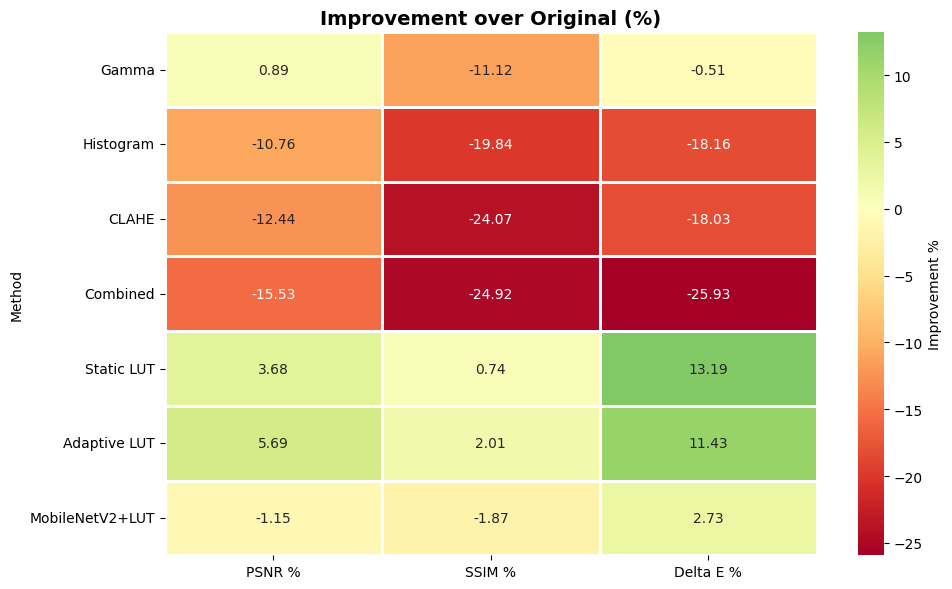

In [3]:
improvement_data = []
for name in method_names:
    m = all_metrics[name]
    improvement_data.append({
        'Method': name,
        'PSNR %': (m['psnr'] - orig['psnr']) / orig['psnr'] * 100,
        'SSIM %': (m['ssim'] - orig['ssim']) / orig['ssim'] * 100,
        'Delta E %': (orig['delta_e'] - m['delta_e']) / orig['delta_e'] * 100,
    })

imp_df = pd.DataFrame(improvement_data).set_index('Method')
print(imp_df.round(2))

plt.figure(figsize=(10, 6))
sns.heatmap(imp_df, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=1, cbar_kws={'label': 'Improvement %'})
plt.title('Improvement over Original (%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/improvement_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Bar Charts by Metric (Blue=Classic, Red=LUT-based)

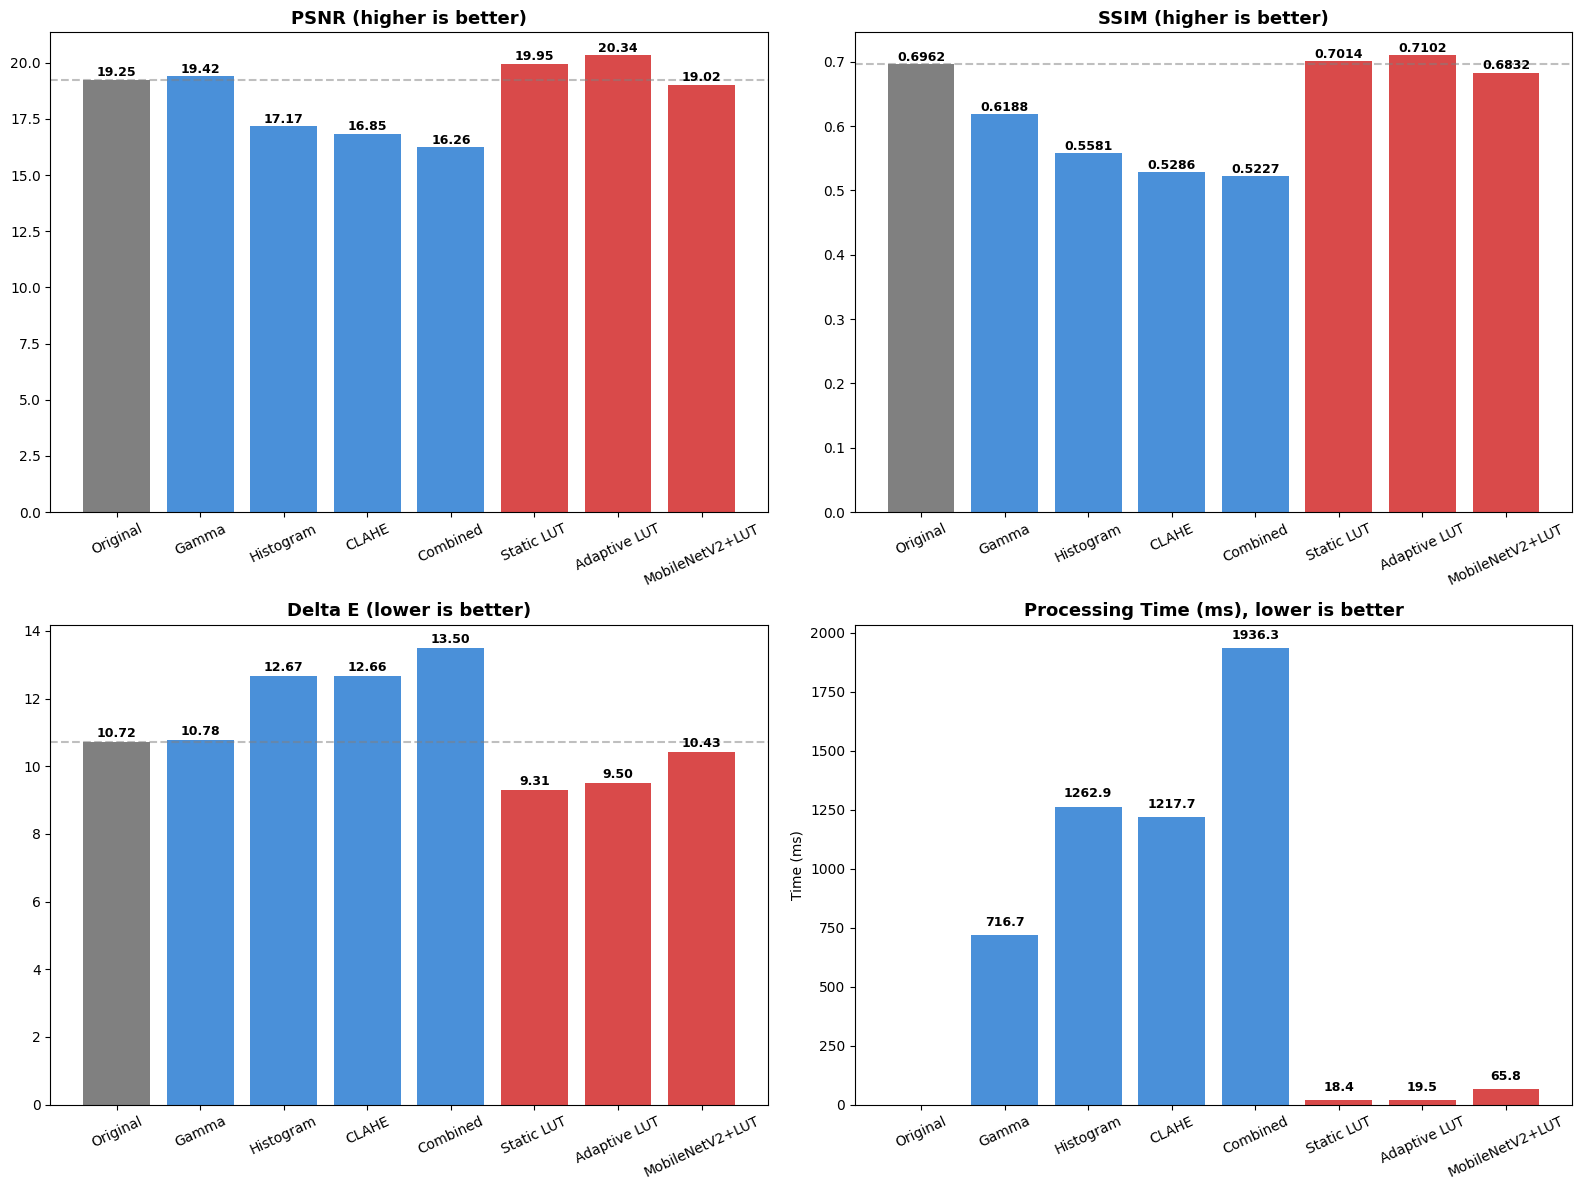

In [4]:
def get_color(name):
    t = all_metrics[name]['type']
    if t == 'Reference': return 'gray'
    elif t == 'Classic': return '#4A90D9'
    else: return '#D94A4A'

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
all_labels = ['Original'] + method_names
all_colors = [get_color(n) for n in all_labels]

psnr_vals = [all_metrics[n]['psnr'] for n in all_labels]
axes[0, 0].bar(all_labels, psnr_vals, color=all_colors)
axes[0, 0].set_title('PSNR (higher is better)', fontsize=13, fontweight='bold')
axes[0, 0].axhline(y=orig['psnr'], color='gray', linestyle='--', alpha=0.5)
for i, v in enumerate(psnr_vals):
    axes[0, 0].text(i, v + 0.15, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=25)

ssim_vals = [all_metrics[n]['ssim'] for n in all_labels]
axes[0, 1].bar(all_labels, ssim_vals, color=all_colors)
axes[0, 1].set_title('SSIM (higher is better)', fontsize=13, fontweight='bold')
axes[0, 1].axhline(y=orig['ssim'], color='gray', linestyle='--', alpha=0.5)
for i, v in enumerate(ssim_vals):
    axes[0, 1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=25)

de_vals = [all_metrics[n]['delta_e'] for n in all_labels]
axes[1, 0].bar(all_labels, de_vals, color=all_colors)
axes[1, 0].set_title('Delta E (lower is better)', fontsize=13, fontweight='bold')
axes[1, 0].axhline(y=orig['delta_e'], color='gray', linestyle='--', alpha=0.5)
for i, v in enumerate(de_vals):
    axes[1, 0].text(i, v + 0.15, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=25)

time_vals = [all_metrics[n]['time_ms'] for n in all_labels]
time_data = [0 if v is None else v for v in time_vals]
axes[1, 1].bar(all_labels, time_data, color=all_colors)
axes[1, 1].set_title('Processing Time (ms), lower is better', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Time (ms)')
for i, v in enumerate(time_vals):
    if v is not None:
        axes[1, 1].text(i, v + max(time_data) * 0.02, f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/metrics_bar_charts.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Model Size Comparison

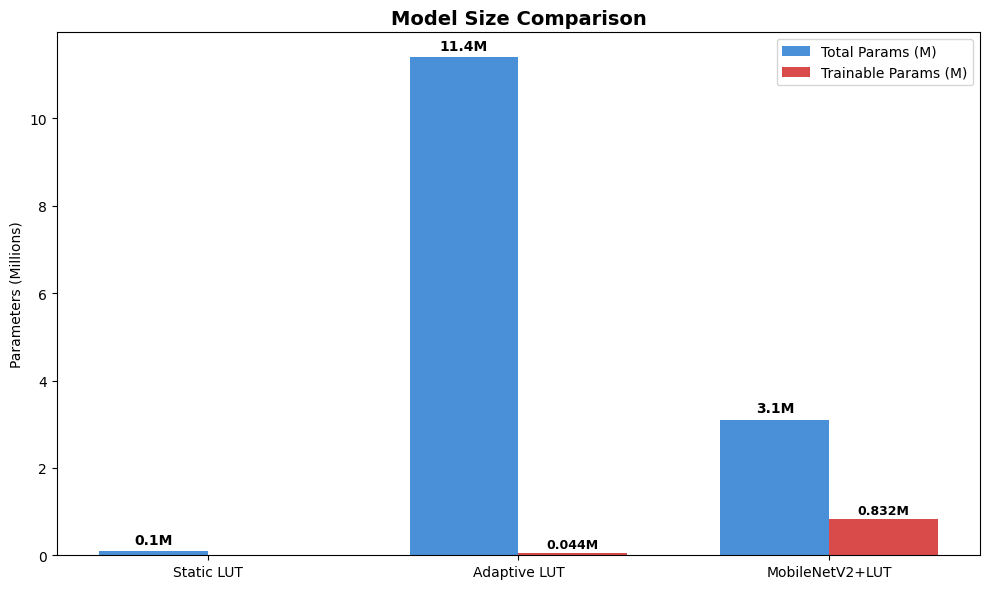

In [6]:
model_methods = [n for n in method_names if all_metrics[n]['params_m'] > 0]
trainable_methods = {'Adaptive LUT': 0.044, 'MobileNetV2+LUT': 0.832}

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(model_methods))
width = 0.35

total_params = [all_metrics[n]['params_m'] for n in model_methods]
trainable_params = [trainable_methods.get(n, 0) for n in model_methods]

bars1 = ax.bar(x - width/2, total_params, width, label='Total Params (M)', color='#4A90D9')
bars2 = ax.bar(x + width/2, trainable_params, width, label='Trainable Params (M)', color='#D94A4A')

ax.set_xticks(x)
ax.set_xticklabels(model_methods)
ax.set_ylabel('Parameters (Millions)')
ax.set_title('Model Size Comparison', fontsize=14, fontweight='bold')
ax.legend()

for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.1, f'{h:.1f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.05, f'{h:.3f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/model_size_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Rankings (1 = Best for Each Metric)

In [9]:
print('=' * 70)
print('KEY INSIGHTS: METHOD COMPARISON')
print('=' * 70)

best_quality = max(method_names, key=lambda n: all_metrics[n]['psnr'] + all_metrics[n]['ssim'] - all_metrics[n]['delta_e']/10)
bm = all_metrics[best_quality]
print(f'1. BEST QUALITY: {best_quality}')
print(f'   PSNR: {orig["psnr"]:.2f} -> {bm["psnr"]:.2f} ({((bm["psnr"]-orig["psnr"])/orig["psnr"])*100:+.1f}%)')
print(f'   Delta E: {orig["delta_e"]:.2f} -> {bm["delta_e"]:.2f} ({((orig["delta_e"]-bm["delta_e"])/orig["delta_e"])*100:+.1f}%)')

fastest = min([n for n in method_names if all_metrics[n]['time_ms'] is not None], key=lambda n: all_metrics[n]['time_ms'])
print(f'2. FASTEST: {fastest} ({all_metrics[fastest]["time_ms"]:.1f} ms)')

qst_methods = [n for n in method_names if all_metrics[n]['time_ms'] is not None]
best_qst = max(qst_methods, key=lambda n: all_metrics[n]['psnr'] / all_metrics[n]['time_ms'])
print(f'3. BEST QUALITY/SPEED: {best_qst} (PSNR/ms = {all_metrics[best_qst]["psnr"]/all_metrics[best_qst]["time_ms"]:.3f})')

model_methods = [n for n in method_names if all_metrics[n]['params_m'] > 0]
lightest = min(model_methods, key=lambda n: all_metrics[n]['params_m'])
print(f'4. LIGHTEST MODEL: {lightest} ({all_metrics[lightest]["params_m"]:.1f}M params)')

print('5. LUT METHODS IMPROVEMENT:')
for n in [m for m in method_names if all_metrics[m]['type'] == 'LUT-based']:
    m = all_metrics[n]
    print(f'   {n:20s}: PSNR {((m["psnr"]-orig["psnr"])/orig["psnr"])*100:+5.1f}%, '
          f'Delta E {((orig["delta_e"]-m["delta_e"])/orig["delta_e"])*100:+5.1f}%, '
          f'{m["time_ms"]:6.1f} ms, {m["params_m"]:4.1f}M params')

print(f'\n{"=" * 70}')

KEY INSIGHTS: METHOD COMPARISON
1. BEST QUALITY: Adaptive LUT
   PSNR: 19.25 -> 20.34 (+5.7%)
   Delta E: 10.72 -> 9.50 (+11.4%)
2. FASTEST: Static LUT (18.4 ms)
3. BEST QUALITY/SPEED: Static LUT (PSNR/ms = 1.084)
4. LIGHTEST MODEL: Static LUT (0.1M params)
5. LUT METHODS IMPROVEMENT:
   Static LUT          : PSNR  +3.7%, Delta E +13.2%,   18.4 ms,  0.1M params
   Adaptive LUT        : PSNR  +5.7%, Delta E +11.4%,   19.5 ms, 11.4M params
   MobileNetV2+LUT     : PSNR  -1.2%, Delta E  +2.7%,   65.8 ms,  3.1M params

